# EAD model and backtest

Mortgage EAD conditional on future default is based on contractual amortisation and an observed balance-at-default adjustment.

In [1]:
from pathlib import Path
import json
import sqlite3
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import roc_auc_score, brier_score_loss, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ROOT = Path.cwd().resolve()
if not (ROOT / "config").exists():
    ROOT = ROOT.parent
DB = ROOT / "database" / "ifrs9_ecl.sqlite3"
CFG = yaml.safe_load((ROOT / "config" / "project.yaml").read_text())

def query(sql):
    with sqlite3.connect(DB) as connection:
        return pd.read_sql_query(sql, connection)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.rcParams["figure.figsize"] = (9, 4)

Development

Target: balance outstanding if default occurs in future month t.

Inputs: current UPB, contractual rate, remaining maturity and observed payoff behaviour.

Method: fixed-rate annuity balance, non-interest-bearing deferred UPB and an observed balance-at-default adjustment.

Tests: one-month forecast MAE, RMSE, MAPE, weighted absolute percentage error and mean error.

No CCF is used because there is no undrawn commitment.

In [2]:
json.loads((ROOT / 'outputs' / 'models' / 'ead_calibration.json').read_text())

{'annual_conditional_prepayment_rate': 0.13891784731598109,
 'monthly_single_mortality': 0.012386429093049545,
 'balance_at_default_adjustment': 1.0018884014023328}

In [3]:
query('select * from ead_backtest_metrics')

,sample,rows,mae_usd,rmse_usd,mape,weighted_absolute_percentage_error,mean_error_usd,target
0,development,583,164.4179,514.5734,0.0011,0.0008,-108.1268,balance in first default month
1,out_of_time,25,183.9952,267.0545,0.0026,0.0015,-183.9952,balance in first default month


In [4]:
ead_sample = query('select * from ead_development_sample')
ead_sample['error'] = ead_sample.predicted_default_balance-ead_sample.actual_default_balance
ead_sample.groupby('split').agg(rows=('loan_id','count'),mae=('error',lambda x:x.abs().mean()),mean_error=('error','mean'))

,rows,mae,mean_error
split,,,
development,583,164.4179,-108.1268
out_of_time,25,183.9952,-183.9952


In [5]:
principal, annual_rate, remaining, month = 200000, 5.0, 360, 12
r = annual_rate/100/12
payment = principal*r/(1-(1+r)**(-remaining))
balance = principal*(1+r)**month-payment*((1+r)**month-1)/r
{'monthly_payment':payment,'balance_after_12_payments':balance}

{'monthly_payment': 1073.6432460242797,
 'balance_after_12_payments': 197049.26930886504}

Text(0.5, 1.0, 'EAD profile')

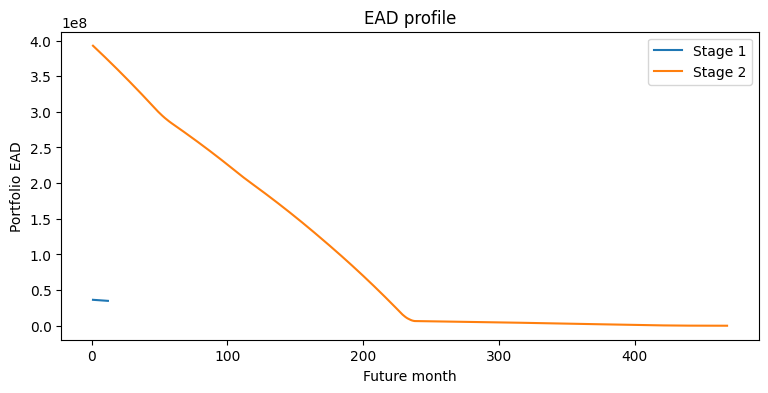

In [6]:
ead = query("select * from ead_profile where stage in (1,2)")
for stage, data in ead.groupby('stage'):
    plt.plot(data.future_month, data.ead, label=f'Stage {stage}')
plt.xlabel('Future month'); plt.ylabel('Portfolio EAD'); plt.legend(); plt.title('EAD profile')

Output: EAD by loan and future month.